<a href="https://colab.research.google.com/github/anishsikdar1102-glitch/anish-sikdar-projects/blob/main/Copy_of_Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

In [13]:
import pandas as pd
import os

# --- ERROR EXPLANATION AND RESOLUTION ---
# The previous error 'FileNotFoundError: [Errno 2] No such file or directory: '/content/Cancer_Data.xlsx''
# means that the Python interpreter could not find the file 'Cancer_Data.xlsx' at the specified path.
#
# To resolve this, please ensure the file is correctly placed in the Colab environment:
#
# 1.  **Upload the file directly:**
#     *   Click the 'Files' icon on the left sidebar (folder icon).
#     *   Click the 'Upload to session storage' icon (page with an arrow pointing up).
#     *   Select your 'Cancer_Data.xlsx' file. It will be uploaded to '/content/'.
#     *   Note: Files uploaded this way are deleted when the Colab runtime restarts.
#
# 2.  **Check file name/path:**
#     *   Verify that the file you uploaded is indeed named 'Cancer_Data.xlsx' (case-sensitive).
#     *   Confirm it's directly in the '/content/' directory.
#
# 3.  **If the file is in Google Drive:**
#     *   You need to mount Google Drive first by running these two lines in a separate cell:
#         *   `from google.colab import drive`
#         *   `drive.mount('/content/drive')`
#     *   Then, update the `file_path` variable below to reflect the correct path in your Drive,
#         e.g., `file_path = '/content/drive/MyDrive/YourFolder/Cancer_Data.xlsx'`
#
# ----------------------------------------

file_path = '/content/cancer_data.csv.csv' # Updated file path to match user's selection

# Check if the file exists before attempting to read it
if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("Please follow the instructions above to upload the 'Cancer_Data.xlsx' file to the '/content/' directory, or update the 'file_path' variable to the correct location.")
    # Raise an error to stop execution and prompt the user to fix the file issue
    raise FileNotFoundError(f"File not found at {file_path}. Please check instructions above.")
else:
    print(f"File '{file_path}' found. Attempting to load...")
    try:
        cancer_data = pd.read_csv(file_path) # Changed to pd.read_csv
        print("Data loaded successfully!")
    except Exception as e:
        print(f"An error occurred while reading the CSV file: {e}")
        print("Please ensure the file is a valid CSV (.csv) format and not corrupted.")

File '/content/cancer_data.csv.csv' found. Attempting to load...
Data loaded successfully!


In [12]:
cancer_data.head()


NameError: name 'cancer_data' is not defined

In [14]:
cancer_data.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
cancer_data.info()

In [ ]:
cancer_data["area_mean"] = cancer_data["area_mean"].fillna(cancer_data["area_mean"].mean())

In [ ]:
# Drop the 'Unnamed: 32' column if it exists
if 'Unnamed: 32' in cancer_data.columns:
    cancer_data = cancer_data.drop('Unnamed: 32', axis=1)
    print("'Unnamed: 32' column dropped.")
else:
    print("'Unnamed: 32' column not found or already dropped.")

In [ ]:
cancer_data.isnull().sum()

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

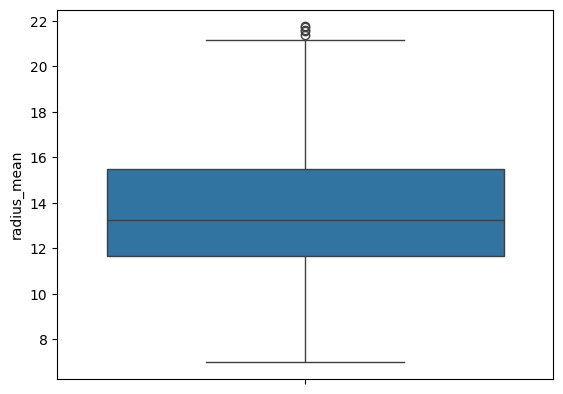

In [18]:
sns.boxplot(cancer_data["radius_mean"])
plt.show()

In [15]:
Q1 = cancer_data["radius_mean"].quantile(0.25)
Q3 = cancer_data["radius_mean"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1, "Q3:", Q3, "IQR:", IQR, "Lower bound:", lower_bound, "Upper bound:", upper_bound)

# Remove outliers from cancer_data
cancer_data = cancer_data[~((cancer_data["radius_mean"] < lower_bound) | (cancer_data["radius_mean"] > upper_bound))]
print("Shape of cancer_data after outlier removal:", cancer_data.shape)

Q1: 11.7 Q3: 15.78 IQR: 4.08 Lower bound: 5.579999999999999 Upper bound: 21.9
Shape of cancer_data after outlier removal: (555, 33)


### IQR Handling: Outlier Capping

Since we previously removed outliers, here's an example of how to handle outliers by **capping** them. This involves setting any value below the `lower_bound` to the `lower_bound`, and any value above the `upper_bound` to the `upper_bound`. First, I'll reload the original dataset to demonstrate this method independently.

In [21]:
# Reload original data to demonstrate capping
cancer_data_capped = pd.read_csv('/content/cancer_data.csv.csv')

# Drop the 'Unnamed: 32' column again
cancer_data_capped = cancer_data_capped.drop('Unnamed: 32', axis=1)

# Recalculate Q1, Q3, IQR, lower_bound, upper_bound for 'radius_mean'
Q1 = cancer_data_capped["radius_mean"].quantile(0.25)
Q3 = cancer_data_capped["radius_mean"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Original 'radius_mean' range: {cancer_data_capped['radius_mean'].min()} - {cancer_data_capped['radius_mean'].max()}")
print(f"Lower Bound (Q1 - 1.5*IQR): {lower_bound}")
print(f"Upper Bound (Q3 + 1.5*IQR): {upper_bound}")

Original 'radius_mean' range: 6.981 - 28.11
Lower Bound (Q1 - 1.5*IQR): 5.579999999999999
Upper Bound (Q3 + 1.5*IQR): 21.9


In [22]:
# Apply capping
cancer_data_capped['radius_mean'] = cancer_data_capped['radius_mean'].clip(lower=lower_bound, upper=upper_bound)

print(f"Capped 'radius_mean' range: {cancer_data_capped['radius_mean'].min()} - {cancer_data_capped['radius_mean'].max()}")
display(cancer_data_capped.head())

Capped 'radius_mean' range: 6.981 - 21.9


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


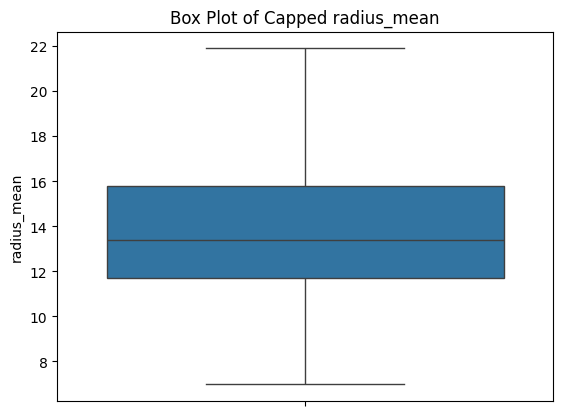

In [23]:
# Visualize the effect of capping with a box plot
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(cancer_data_capped["radius_mean"])
plt.title('Box Plot of Capped radius_mean')
plt.show()

### Data Splitting: Features, Target, and Train/Test Sets

Now, let's prepare the data for a machine learning model by separating the features (X) from the target variable (y). The 'diagnosis' column is our target. We'll convert it to numerical values (M=1, B=0) and then split the data into training and testing sets.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Drop the 'id' column as it's not a feature for prediction
# Ensure 'diagnosis' is not dropped twice if it's already removed, or handle other non-feature columns
X = cancer_data.drop(['id', 'diagnosis'], axis=1)
y = cancer_data['diagnosis']

# Encode the target variable 'diagnosis' (M=1, B=0)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y_encoded.shape)
print("Target classes:", label_encoder.classes_)

Features (X) shape: (555, 31)
Target (y) shape: (555,)
Target classes: ['B' 'M']


In [25]:
# Split the data into training and testing sets
# We'll use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (444, 31)
X_test shape: (111, 31)
y_train shape: (444,)
y_test shape: (111,)


In [27]:
# The label_encoder object from cell 296242c5 contains the mapping
# Display the classes and their encoded values

print(f"Original classes: {label_encoder.classes_}")
print(f"Encoded values: {label_encoder.transform(label_encoder.classes_)}")

# You can also see the first few encoded target values
print("\nFirst 5 encoded target values (y_encoded):")
print(y_encoded[:5])

print("\nFirst 5 encoded target values in y_train:")
print(y_train[:5])

print("\nFirst 5 encoded target values in y_test:")
print(y_test[:5])

Original classes: ['B' 'M']
Encoded values: [0 1]

First 5 encoded target values (y_encoded):
[1 1 1 1 1]

First 5 encoded target values in y_train:
[0 1 0 0 0]

First 5 encoded target values in y_test:
[1 0 0 0 1]


### Feature Scaling

Feature scaling is applied to the features (X_train and X_test) to standardize their range. We will use `StandardScaler` to transform the data such that it has a mean of 0 and a standard deviation of 1. It's important to fit the scaler *only* on the training data (`X_train`) and then transform both `X_train` and `X_test` using this fitted scaler to avoid data leakage from the test set.

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Initialize the SimpleImputer to fill missing values with the mean
# Fit on X_train and transform both X_train and X_test to avoid data leakage
imputer = SimpleImputer(strategy='mean')

# Impute missing values in X_train and X_test
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the imputed training data (X_train_imputed) and transform it
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Transform the imputed test data (X_test_imputed) using the *same* fitted scaler
X_test_scaled = scaler.transform(X_test_imputed)

print("Shape of scaled X_train:", X_train_scaled.shape)
print("Shape of scaled X_test:", X_test_scaled.shape)

# Display a few scaled values (e.g., first 5 rows and first 5 columns of X_train_scaled)
print("\nFirst 5 rows and 5 columns of scaled X_train:")
print(X_train_scaled[:5, :5])

print("\nFirst 5 rows and 5 columns of scaled X_test:")
print(X_test_scaled[:5, :5])

Shape of scaled X_train: (444, 30)
Shape of scaled X_test: (111, 30)

First 5 rows and 5 columns of scaled X_train:
[[-0.76073636 -0.19913777 -0.78756389 -0.74621141 -0.14425101]
 [-0.66554203 -0.65563878 -0.52398248 -0.66293084  0.9905064 ]
 [-0.65284945 -0.07951985 -0.68462404 -0.6764724  -0.48794111]
 [-0.62111801 -0.25040259 -0.67539176 -0.64397267 -0.93024272]
 [-0.44659506 -0.58972687 -0.5147502  -0.49501555 -0.74897157]]

First 5 rows and 5 columns of scaled X_test:
[[-0.05947144  0.38186353 -0.00651354 -0.16900259  1.70108931]
 [-0.58304027 -0.08928458 -0.63153846 -0.61790517 -0.83960715]
 [-1.01141477  0.27445153 -0.96205386 -0.95779823  0.92524878]
 [-1.58956168 -1.12922807 -1.45644212 -1.29938398  0.17333605]
 [ 1.13045771  4.88584416  1.06443021  0.99117023  0.1943635 ]]


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Unnamed: 32']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


### Model Training and Evaluation

Now that our data is preprocessed, let's train and evaluate several classification models. We'll use `accuracy_score` and `classification_report` to assess their performance.

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Ensure X_train_scaled and y_train are defined from previous preprocessing steps
if 'X_train_scaled' not in locals() and 'X_train_scaled' not in globals():
    raise NameError("X_train_scaled is not defined. Please ensure all preceding data preprocessing and feature scaling cells have been run successfully.")
if 'y_train' not in locals() and 'y_train' not in globals():
    raise NameError("y_train is not defined. Please ensure all preceding data preprocessing and data splitting cells have been run successfully.")

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    print(f"\n--- Training {name} ---")
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    results[name] = {"accuracy": accuracy, "report": report}

    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(report)


--- Training Logistic Regression ---
Accuracy: 0.9820
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        71
           1       0.97      0.97      0.97        40

    accuracy                           0.98       111
   macro avg       0.98      0.98      0.98       111
weighted avg       0.98      0.98      0.98       111


--- Training Random Forest ---
Accuracy: 0.9820
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.97        40

    accuracy                           0.98       111
   macro avg       0.99      0.97      0.98       111
weighted avg       0.98      0.98      0.98       111


--- Training Decision Tree ---
Accuracy: 0.9099
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        71
           1   

### Summary of Model Performance

In [30]:
print("\n--- Model Performance Summary ---")
for name, metrics in results.items():
    print(f"\n{name}:")
    print(f"  Accuracy: {metrics['accuracy']:.4f}")
    print("  Classification Report:\n" + metrics['report'])


--- Model Performance Summary ---

Logistic Regression:
  Accuracy: 0.9820
  Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        71
           1       0.97      0.97      0.97        40

    accuracy                           0.98       111
   macro avg       0.98      0.98      0.98       111
weighted avg       0.98      0.98      0.98       111


Random Forest:
  Accuracy: 0.9820
  Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.97        40

    accuracy                           0.98       111
   macro avg       0.99      0.97      0.98       111
weighted avg       0.98      0.98      0.98       111


Decision Tree:
  Accuracy: 0.9099
  Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        71
           1    